In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

# 全局设置
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

FILE_PATH = './Data/Online_Retail_Cleaned.xlsx'


def load_data():
    """读取清洗后的数据"""
    print("正在读取数据...")
    df = pd.read_excel(FILE_PATH)
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
    # 只取正常订单做分析
    df = df[~df['InvoiceNo'].astype(str).str.startswith('C', na=False)].copy()
    print(f"数据加载完成，共 {len(df):,} 条记录")
    return df

df = load_data()

正在读取数据...
数据加载完成，共 383,139 条记录



【方法1】K-means 聚类分析
参与聚类的客户数: 4321


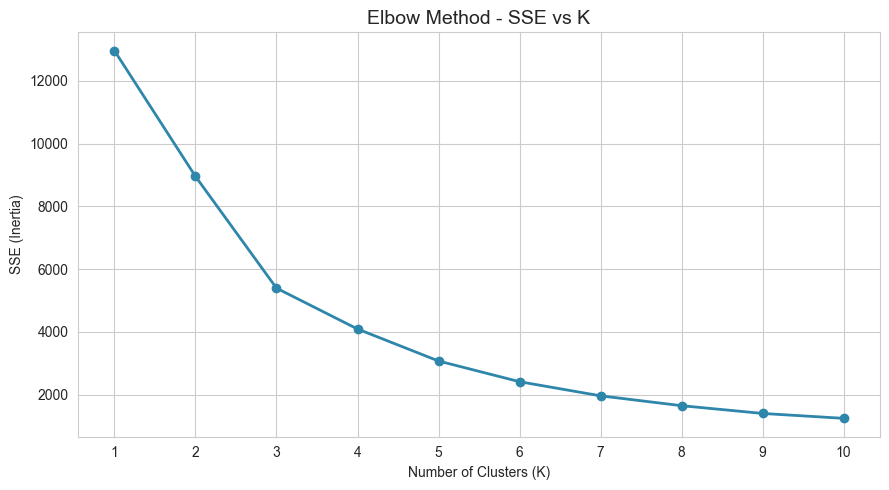

肘部图已保存: ./kmeans_elbow.png（请观察拐点确定最佳K）
自动建议最佳K = 6（也可手动修改下方 K 值）


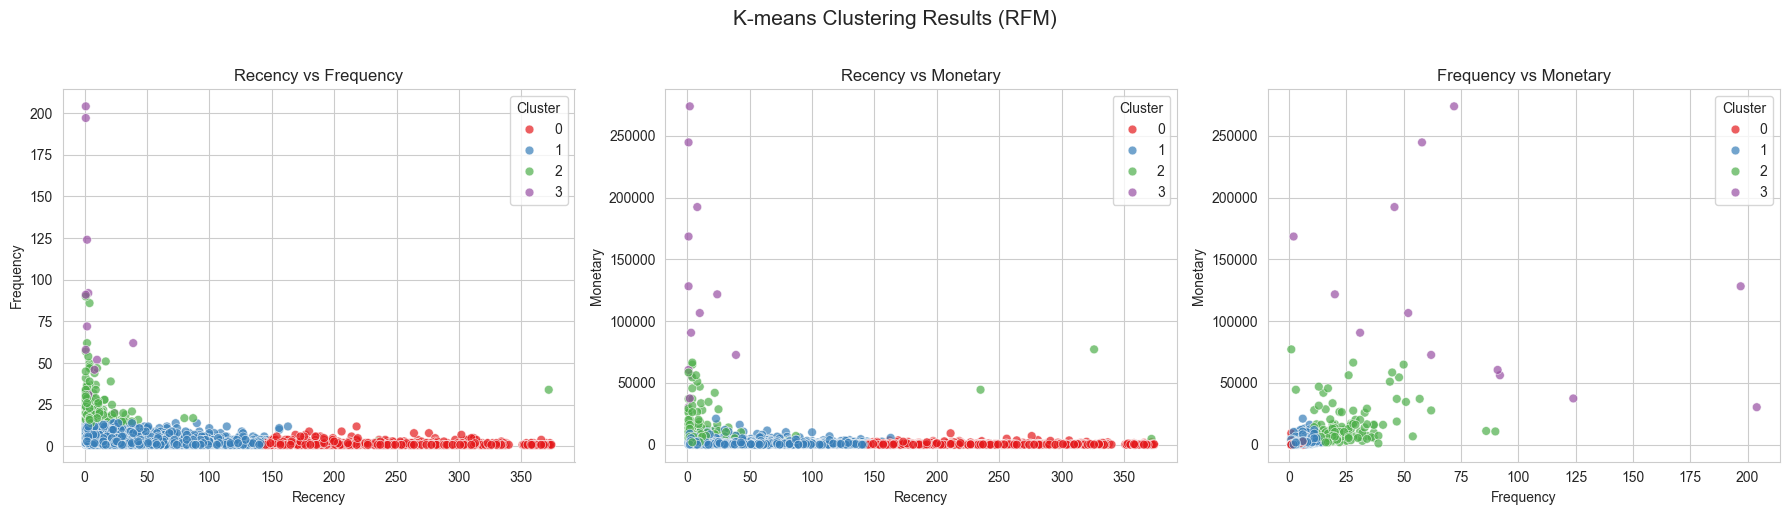


各聚类簇特征（均值）:
         Recency  Frequency   Monetary   客户数
Cluster                                     
0         248.27       1.55     450.08  1060
1          43.55       3.69    1301.73  3059
2          14.05      22.98   12386.32   189
3           7.38      80.85  121827.45    13

结果已保存: kmeans_cluster_summary.xlsx, kmeans_rfm_result.xlsx


In [ ]:
# 方法 1：K-means 聚类分析（基于 RFM 特征）

def kmeans_analysis(df):
    print("\n" + "=" * 60)
    print("【方法1】K-means 聚类分析")
    print("=" * 60)

    # 1. 构建 RFM 特征
    snapshot_date = df['InvoiceDate'].max() + timedelta(days=1)  # 参考日期
    rfm = df.groupby('CustomerID').agg({
        'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
        'InvoiceNo': 'nunique',                                    # Frequency
        'TotalAmount': 'sum'                                       # Monetary
    }).reset_index()
    rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
    print(f"参与聚类的客户数: {len(rfm)}")

    # 2. 标准化
    features = ['Recency', 'Frequency', 'Monetary']
    scaler = StandardScaler()
    rfm_scaled = scaler.fit_transform(rfm[features])

    # 3. 肘部法选择 K
    sse = []
    K_range = range(1, 11)
    for k in K_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(rfm_scaled)
        sse.append(km.inertia_)

    plt.figure(figsize=(9, 5))
    plt.plot(list(K_range), sse, marker='o', linewidth=2, color='#2E86AB')
    plt.title('Elbow Method - SSE vs K', fontsize=14)
    plt.xlabel('Number of Clusters (K)')
    plt.ylabel('SSE (Inertia)')
    plt.xticks(list(K_range))
    plt.tight_layout()
    plt.savefig('./kmeans_elbow.png', dpi=300)
    plt.show()
    print("肘部图已保存: ./kmeans_elbow.png（请观察拐点确定最佳K）")

    # 4. 自动选择最佳K（肘部法简化版）
    # 计算相邻点斜率差，找拐点
    sse_diff = np.diff(sse)
    k_best = int(np.argmin(np.abs(sse_diff - np.median(sse_diff)))) + 2
    k_best = max(3, min(k_best, 6))  # 限制在合理范围
    print(f"自动建议最佳K = {k_best}")

    # 5. 执行聚类
    # 观测后k = 4 时曲线放缓，所以选择4而不是k_best(6)
    K = 4
    kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
    rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

    # 6. 聚类结果可视化
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    pairs = [('Recency', 'Frequency'), ('Recency', 'Monetary'), ('Frequency', 'Monetary')]
    for ax, (x, y) in zip(axes, pairs):
        sns.scatterplot(data=rfm, x=x, y=y, hue='Cluster', palette='Set1', ax=ax, s=40, alpha=0.7)
        ax.set_title(f'{x} vs {y}')
    plt.suptitle('K-means Clustering Results (RFM)', fontsize=15, y=1.02)
    plt.tight_layout()
    plt.savefig('./kmeans_clusters.png', dpi=300, bbox_inches='tight')
    plt.show()

    # 7. 输出各簇特征
    cluster_summary = rfm.groupby('Cluster')[features].mean().round(2)
    cluster_summary['客户数'] = rfm.groupby('Cluster').size()
    print("\n各聚类簇特征（均值）:")
    print(cluster_summary)
    cluster_summary.to_excel('./kmeans_cluster_summary.xlsx')
    rfm.to_excel('./kmeans_rfm_result.xlsx', index=False)
    print("\n结果已保存: kmeans_cluster_summary.xlsx, kmeans_rfm_result.xlsx")


# 运行方法1
kmeans_analysis(df)

# 客户分类（基于k-means聚类）
| 客户分群 | 客户数量与占比 | 核心 RFM 特征 | 客户画像与运营建议 |
| :--- | :--- | :--- | :--- |
| Cluster 3<br>顶级VIP客户 | 13人<br>(0.3%) | R: 7.38天 (极活跃)<br>F: 80.85次 (极高)<br>M: £121,827 (极高) | 画像： 超大批发商或核心分销商，呈现极高频率、极大金额的持续性采购特征。<br>建议： 不可替代的战略级客户资源，对企业营收有决定性影响，需重点维系。 |
| Cluster 2<br>高价值忠诚客户 | 189人<br>(4.4%) | R: 14.05天 (活跃)<br>F: 22.98次 (高)<br>M: £12,386 (高) | 画像： 已形成稳定采购周期与高复购频次的高频高额稳定型客户。<br>建议： 企业利润的重要贡献者，需重点维护和持续培育的核心资产。 |
| Cluster 1<br>中坚潜力客户 | 3,059人<br>(70.8%) | R: 43.55天 (中等)<br>F: 3.69次 (中等)<br>M: £1,302 (中等) | 画像： 客户群绝对主体，多为中小型批发商，有一定复购习惯但规模有限。<br>建议： 精准运营的重点目标，若能通过运营手段将其部分向 Cluster 2 迁移，将带来显著营收增长。 |
| Cluster 0<br>流失风险客户 | 1,060人<br>(24.5%) | R: 248天 (极不活跃)<br>F: 1.55次 (极低)<br>M: £450 (低) | 画像： 典型的“一次性交易后流失”特征，处于生命周期衰退期或流失期。<br>建议： 虽个体金额不高，但基数大（近1/4），若不干预将导致客户基数持续流失，需采取挽回措施。 |

## 客户分析

**1. 客户价值呈极端金字塔结构（帕累托法则验证）**
*   **现象**：仅占总数 **4.7%** 的顶级VIP（Cluster 3）与高价值客户（Cluster 2），其人均消费金额远超其余 95% 的客户。
*   **风险**：客户集中度极高，若 Cluster 3 中的少数顶级客户流失，将对整体营收造成重大冲击。

**2. 主体客群（Cluster 1）运营提效空间巨大**
*   **现状**：Cluster 1 占据 **70.8%** 的客户基数，但平均消费金额仅为 Cluster 2 的十分之一。
*   **机会**：巨大的价值落差意味着极高的增长潜力。若能通过精准运营（如个性化推荐、阶梯折扣）促使 **10%** 的 Cluster 1 客户向 Cluster 2 跃迁，将带来可观的增量收入。

**3. 近四分之一客户面临流失风险（Cluster 0）**
*   **现状**：约 **24.5%** 的客户平均 Recency 超过 8 个月，基本处于流失状态。
*   **策略**：需平衡唤醒成本与收益。对历史消费较高的客户尝试定向召回（专属优惠）；对极低价值客户降低资源投入，将有限资源向高潜力群体倾斜。

**4. B2B 批发场景特征显著**
*   **验证**：Cluster 3 和 Cluster 2 呈现出高频次（数十至上百次）、大金额（数万至十余万英镑）的采购模式，验证了企业以批发商为核心的 B2B 属性。
*   **方向**：运营策略不应照搬 C 端促销，而应围绕批发场景设计，如**批量采购折扣体系**、**定期补货提醒**、**专属客户经理服务**等。



【方法2】分类分析（RFM 模型 + BCG 矩阵）

--- Part A: 用户 RFM 模型 ---


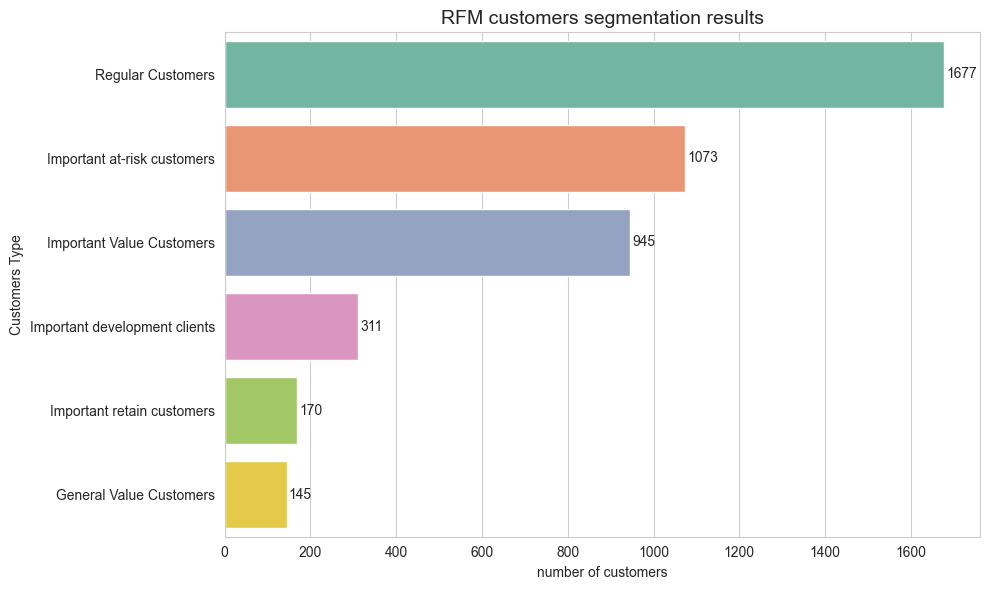

RFM 用户分层统计:
用户类型
Regular Customers                1677
Important at-risk customers      1073
Important Value Customers         945
Important development clients     311
Important retain customers        170
General Value Customers           145
Name: count, dtype: int64
已保存: rfm_user_classification.xlsx

--- Part B: 商品 BCG 矩阵 ---


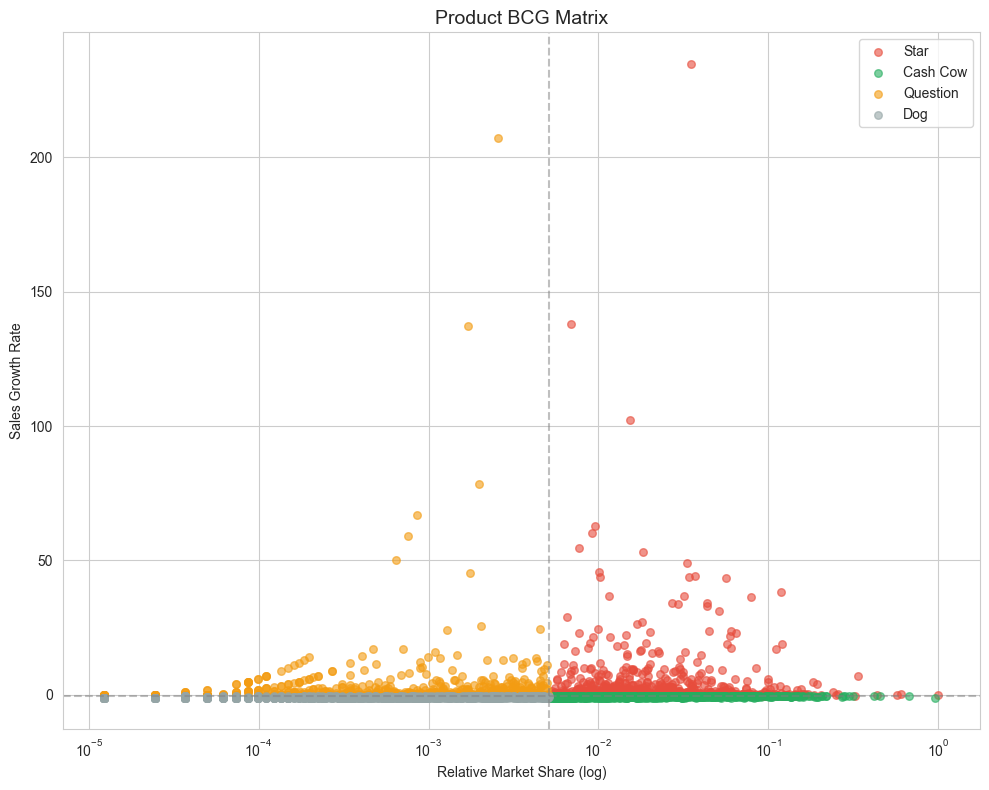

BCG 分类统计:
BCG类型
Star        992
Dog         991
Cash Cow    802
Question    801
Name: count, dtype: int64
已保存: bcg_product_classification.xlsx


In [3]:
# 方法 2：分类分析（RFM 模型 + BCG 矩阵）

def classification_analysis(df):
    print("\n" + "=" * 60)
    print("【方法2】分类分析（RFM 模型 + BCG 矩阵）")
    print("=" * 60)

    snapshot_date = df['InvoiceDate'].max() + timedelta(days=1)

    # Part A: 用户 RFM 模型
    print("\n--- Part A: 用户 RFM 模型 ---")
    rfm = df.groupby('CustomerID').agg({
        'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
        'InvoiceNo': 'nunique',
        'TotalAmount': 'sum'
    }).reset_index()
    rfm.columns = ['CustomerID', 'R', 'F', 'M']

    # 五分位打分（1-5分），R 越小分越高，F/M 越大分越高
    rfm['R_Score'] = pd.qcut(rfm['R'].rank(method='first'), 5, labels=[5, 4, 3, 2, 1]).astype(int)
    rfm['F_Score'] = pd.qcut(rfm['F'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
    rfm['M_Score'] = pd.qcut(rfm['M'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
    rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

    # 用户分层映射
    def rfm_segment(row):
        r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
        if r >= 4 and f >= 4 and m >= 4:
            return 'Important Value Customers'
        elif r >= 4 and f <= 2:
            return 'Important development clients'
        elif r <= 2 and f >= 4 and m >= 4:
            return 'Important retain customers'
        elif r <= 2 and f <= 2:
            return 'Important at-risk customers'
        elif r >= 4 and f >= 2 and m <= 2:
            return 'General Value Customers'
        else:
            return 'Regular Customers'
    rfm['用户类型'] = rfm.apply(rfm_segment, axis=1)

    # 可视化
    plt.figure(figsize=(10, 6))
    seg_count = rfm['用户类型'].value_counts()
    sns.barplot(x=seg_count.values, y=seg_count.index, palette='Set2')
    plt.title('RFM customers segmentation results', fontsize=14)
    plt.xlabel('number of customers')
    plt.ylabel('Customers Type')
    for i, v in enumerate(seg_count.values):
        plt.text(v + 5, i, str(v), va='center', fontsize=10)
    plt.tight_layout()
    plt.savefig('./rfm_segments.png', dpi=300)
    plt.show()

    print("RFM 用户分层统计:")
    print(seg_count)
    rfm.to_excel('./rfm_user_classification.xlsx', index=False)
    print("已保存: rfm_user_classification.xlsx")

    # Part B: 商品 BCG 矩阵
    print("\n--- Part B: 商品 BCG 矩阵 ---")
    # 计算每个商品的总销量（份额代理）和增长率（后半年 vs 前半年）
    df['Period'] = np.where(df['InvoiceDate'] >= df['InvoiceDate'].quantile(0.5), 'H2', 'H1')
    bcg = df.groupby(['StockCode', 'Period'])['Quantity'].sum().unstack(fill_value=0)
    if 'H1' not in bcg.columns:
        bcg['H1'] = 0
    if 'H2' not in bcg.columns:
        bcg['H2'] = 0

    # 增长率 = (H2 - H1) / (H1 + 1)  （+1 避免除零）
    bcg['增长率'] = (bcg['H2'] - bcg['H1']) / (bcg['H1'].replace(0, np.nan))
    bcg['增长率'] = bcg['增长率'].fillna(0)
    # 相对市场份额 = 商品总销量 / 最大商品销量
    bcg['总销量'] = bcg['H1'] + bcg['H2']
    bcg['相对份额'] = bcg['总销量'] / bcg['总销量'].max()
    bcg = bcg.reset_index()

    # 用中位数划分高低
    growth_median = bcg['增长率'].median()
    share_median = bcg['相对份额'].median()

    def bcg_classify(row):
        high_growth = row['增长率'] >= growth_median
        high_share = row['相对份额'] >= share_median
        if high_growth and high_share:
            return 'Star'
        elif not high_growth and high_share:
            return 'Cash Cow'
        elif high_growth and not high_share:
            return 'Question'
        else:
            return 'Dog'
    bcg['BCG类型'] = bcg.apply(bcg_classify, axis=1)

    # BCG 散点图（为可视化清晰，取对数缩放）
    plt.figure(figsize=(10, 8))
    colors = {'Star': '#E74C3C', 'Cash Cow': '#27AE60',
              'Question': '#F39C12', 'Dog': '#95A5A6'}
    for cat, color in colors.items():
        sub = bcg[bcg['BCG类型'] == cat]
        plt.scatter(sub['相对份额'], sub['增长率'], s=30, c=color, label=cat, alpha=0.6)
    plt.axvline(share_median, color='gray', linestyle='--', alpha=0.5)
    plt.axhline(growth_median, color='gray', linestyle='--', alpha=0.5)
    plt.xscale('log')
    plt.title('Product BCG Matrix', fontsize=14)
    plt.xlabel('Relative Market Share (log)')
    plt.ylabel('Sales Growth Rate')
    plt.legend()
    plt.tight_layout()
    plt.savefig('./bcg_matrix.png', dpi=300)
    plt.show()

    print("BCG 分类统计:")
    print(bcg['BCG类型'].value_counts())
    bcg.to_excel('./bcg_product_classification.xlsx', index=False)
    print("已保存: bcg_product_classification.xlsx")


# 运行方法2
classification_analysis(df)

# 客户分类（基于RFM模型）
| 客户分群 | 客户数量与占比 | 核心 RFM 特征 | 典型客户示例 | 运营策略建议 |
| :--- | :--- | :--- | :--- | :--- |
| 重要价值客户 | 945人<br>(21.9%) | R、F、M 均高于均值<br>(高活跃、高忠诚、高消费) | 客户12347<br>(R=2天, F=7次, M=£4,119) | 配置专属客户经理、优先新品体验权、阶梯返利等 VIP 权益，锁定长期合作。 |
| 重要风险客户 | 1,073人<br>(24.8%) | 高 M、低 R<br>(历史高消费，近期未购买) | 客户12346<br>(R=326天, F=1次, M=£77,184) | 立即启动定向召回，如专属优惠券、限时折扣、老客专享新品等。 |
| 常规客户 | 1,677人<br>(38.8%) | R、F、M 处于中等水平<br>(有复购但不频繁，金额中等) | 客户12348<br>(R=75天, F=4次, M=£1,437) | 通过会员积分、满额赠礼、采购周期提醒等方式，稳步提升购买频次与客单价。 |
| 重要发展客户 | 311人<br>(7.2%) | 高 R、高 M、低 F<br>(近期活跃且金额高，但频次低) | 客户12357<br>(R=33天, F=1次, M=£5,961) | 加强客户教育，推出"复购折扣"或"周期订购"服务，引导建立定期采购习惯。 |
| 重要留存客户 | 170人<br>(3.9%) | 高 F、高 M、低 R<br>(历史频次高，但近期购买时间远) | 客户12383<br>(R=185天, F=5次, M=£1,603) | 温和召回，如发送"常购商品已补货"提醒，或针对历史偏好推送关联商品。 |
| 普通价值客户 | 145人<br>(3.4%) | 高 R、高 F、低 M<br>(近期活跃且频次尚可，但金额低) | 客户12464<br>(R=10天, F=7次, M=£213) | 通过捆绑销售、满额升级提升客单价；若提升空间有限，可降低维护成本，采用自动化营销。 |

## k-means和RFM验证分析
  对比K-means聚类（4簇）与RFM分层（6类型）的结果，两者呈现出高度一致的逻辑互补性。K-means的Cluster 3（顶级VIP）和Cluster 2（高价值忠诚）在RFM中主要对应"重要价值客户"；K-means的Cluster 0（流失风险）在RFM中主要对应"重要风险客户"和"重要留存客户"；K-means的Cluster 1（中坚潜力）则大量分布在"常规客户"和"重要发展客户"中。RFM分层通过业务规则提供了更细粒度的语义标签，而K-means通过距离聚类揭示了数据驱动的自然簇结构。两种方法交叉验证，增强了客户分群结论的稳健性。

# 商品分类（BCG矩阵）
| 产品类别 | 矩阵位置与特征 | 典型商品示例 | 运营策略建议 |
| :--- | :--- | :--- | :--- |
| 现金牛产品<br>(Cash Cow) | 右下角<br>高相对市场份额、负增长或低增长 | 21212（份额0.416，销量33,670）<br>17003（份额0.283，销量22,927）<br>15036（份额0.270，销量21,876） | 策略重心为"收割"：维持库存深度、保障供应稳定、适度控制营销投入，最大化利润贡献。 |
| 明星产品<br>(Star) | 左上至中央区域<br>高增长、高份额 | 20668（份额0.156，增长率213%）<br>16008（份额0.036，增长率329%）<br>16169E（份额0.056，增长率4,263%） | 加大资源倾斜：确保库存充足、扩大采购规模、给予首页推荐或捆绑引流，推动其向现金牛演进。 |
| 问题产品<br>(Question) | 左上区域<br>低份额、高增长（多为低基数效应） | 10080（增长率193%）<br>20831（增长率345%）<br>21261（增长率2,550%） | 甄别真正具有品类创新价值的单品进行小规模试销培育；对缺乏延展性的长尾产品避免盲目投入。 |
| 瘦狗产品<br>(Dog) | 左下角<br>低份额、负增长，数量庞大但单量微弱 | 10123C（总销量5）<br>16010（总销量30）<br>17007B（总销量24） | 系统性 SKU 清理：长期零动销商品果断下架，偶发性需求商品转为"以销定采"预售模式，释放运营资源。 |

## 商品分析
**1. 商品结构特征：头部集中，尾部冗长**
*   **现象**：少数现金牛和明星产品贡献了绝大部分销量，而大量瘦狗SKU仅贡献了极微薄的销售。
*   **背景**：这符合全场合礼品批发商的业务特性——爆款（如节日装饰品）具有普适性需求，而长尾SKU则用于覆盖特定细分场景。

**2. 品类优化策略：建立迭代机制**
*   **核心逻辑**：以现金牛养明星、以明星替瘦狗。
*   **现金牛**：通过供应链谈判降低采购成本，延长利润周期。
*   **明星产品**：加速补货周期，防止断货错失增长窗口。
*   **瘦狗产品**：设置明确的清退阈值（如连续两个季度销量低于中位数10%），定期进行SKU瘦身。

**3. 库存与采购策略：量化库存结构**
*   **现金牛**：保持安全库存，避免缺货影响现金流。
*   **明星产品**：动态调整库存策略，配合增长趋势提前备货。
*   **问题产品**：高潜力单品可小批量试销，以最小化库存风险。
*   **瘦狗产品**：严格限制库存投入，优先以订单驱动采购（以销定采）。

**4. 定价与促销策略：差异化定价**
*   **现金牛**：市场地位稳固，具备一定定价权，可适度提价以提升毛利率。
*   **明星产品**：以市场份额为导向，维持竞争性定价。
*   **问题产品**：潜力单品可通过限时促销测试价格弹性。
*   **瘦狗产品**：通过清仓折扣快速回笼资金。


【方法3】关联性分析（Apriori 算法）
英国市场订单数: 16,505
挖掘频繁项集（min_support=0.02）...


c:\Users\jimc\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


发现频繁项集: 285 个
生成关联规则: 20 条（已按提升度排序取Top20）

--------------------------------------------------
【关联规则三指标解读】
--------------------------------------------------
1. Support（支持度）= 同时包含A和B的交易数 / 总交易数
   含义: A和B一起出现的普遍程度。值越高越常见。
2. Confidence（置信度）= P(B|A) = 买A时也买B的概率
   含义: 买了A后购买B的可靠性。0~1，越高越可靠。
3. Lift（提升度）= Confidence / P(B) = P(A∩B) / [P(A)×P(B)]
   含义: 买A对买B的提升程度。
   >1 正相关（互相促进），=1 独立无关，<1 负相关。
--------------------------------------------------

Top 20 关联规则:
 antecedents  consequents  support  confidence    lift
22697, 22699        22698   0.0223      0.7164 22.4468
       22698 22697, 22699   0.0223      0.6973 22.4468
22698, 22699        22697   0.0223      0.8903 22.3270
       22697 22698, 22699   0.0223      0.5581 22.3270
       22698        22697   0.0264      0.8262 20.7179
       22697        22698   0.0264      0.6612 20.7179
       22629        22630   0.0204      0.6186 20.2952
       22630        22629   0.0204      0.6702 20.2952
22698, 22697        22699   0.0223      0.84

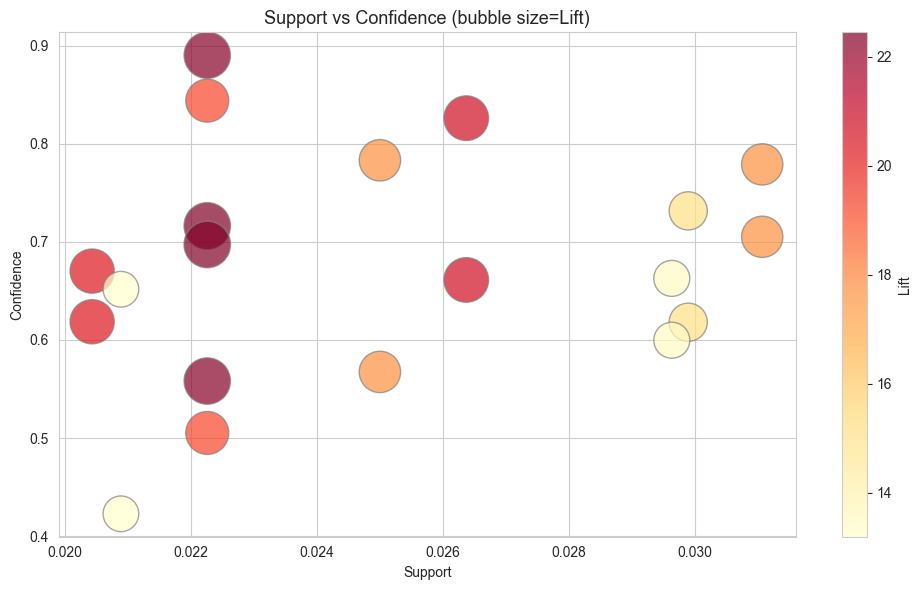

In [4]:
# 方法 3：关联性分析（Apriori，含三指标解读）

def association_analysis(df):
    print("\n" + "=" * 60)
    print("【方法3】关联性分析（Apriori 算法）")
    print("=" * 60)
    try:
        from mlxtend.frequent_patterns import apriori, association_rules
    except ImportError:
        print("缺少 mlxtend 库，请先安装: pip install mlxtend")
        return

    # 1. 数据量大，先采样/过滤
    # 只取英国市场，且过滤掉下单商品种类过少（<=1）的订单
    df_uk = df[df['Country'] == 'United Kingdom'].copy()
    print(f"英国市场订单数: {df_uk['InvoiceNo'].nunique():,}")

    # 构建购物篮：行=InvoiceNo，列=StockCode，值=是否购买
    basket = df_uk.groupby(['InvoiceNo', 'StockCode'])['Quantity'].sum().unstack(fill_value=0)
    # 转为 one-hot（买过为1）
    basket = (basket > 0).astype(int)
    # 只保留商品数 >=2 的订单（有关联意义）
    basket = basket[basket.sum(axis=1) >= 2]

    # 2. Apriori 挖掘频繁项集
    # min_support 可调；数据量大时调高以提高速度
    min_support = 0.02
    print(f"挖掘频繁项集（min_support={min_support}）...")
    frequent = apriori(basket, min_support=min_support, use_colnames=True)
    print(f"发现频繁项集: {len(frequent)} 个")
    if frequent.empty:
        print("未发现频繁项集，请降低 min_support 后重试。")
        return

    # 3. 生成关联规则
    rules = association_rules(frequent, metric='lift', min_threshold=1)
    rules = rules.sort_values('lift', ascending=False).head(20)
    print(f"生成关联规则: {len(rules)} 条（已按提升度排序取Top20）")

    # 4. 三指标解读
    print("\n" + "-" * 50)
    print("【关联规则三指标解读】")
    print("-" * 50)
    print("1. Support（支持度）= 同时包含A和B的交易数 / 总交易数")
    print("   含义: A和B一起出现的普遍程度。值越高越常见。")
    print("2. Confidence（置信度）= P(B|A) = 买A时也买B的概率")
    print("   含义: 买了A后购买B的可靠性。0~1，越高越可靠。")
    print("3. Lift（提升度）= Confidence / P(B) = P(A∩B) / [P(A)×P(B)]")
    print("   含义: 买A对买B的提升程度。")
    print("   >1 正相关（互相促进），=1 独立无关，<1 负相关。")
    print("-" * 50)

    # 展示规则（格式化输出）
    display_cols = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
    rules_display = rules[display_cols].copy()
    rules_display['antecedents'] = rules_display['antecedents'].apply(lambda x: ', '.join(list(x)))
    rules_display['consequents'] = rules_display['consequents'].apply(lambda x: ', '.join(list(x)))
    rules_display['support'] = rules_display['support'].round(4)
    rules_display['confidence'] = rules_display['confidence'].round(4)
    rules_display['lift'] = rules_display['lift'].round(4)
    print("\nTop 20 关联规则:")
    print(rules_display.to_string(index=False))

    rules.to_excel('./association_rules.xlsx', index=False)
    print("\n已保存: association_rules.xlsx")

    # 5. 可视化
    plt.figure(figsize=(10, 6))
    plt.scatter(rules['support'], rules['confidence'],
                s=rules['lift'] * 50, c=rules['lift'], cmap='YlOrRd', alpha=0.7, edgecolors='gray')
    plt.colorbar(label='Lift')
    plt.xlabel('Support')
    plt.ylabel('Confidence')
    plt.title('Support vs Confidence (bubble size=Lift)', fontsize=13)
    plt.tight_layout()
    plt.savefig('./association_rules_scatter.png', dpi=300)
    plt.show()


# 运行方法3
association_analysis(df)

# 商品关联性分析
## 组合一 ：{22697, 22698, 22699} ——— 三件套核心组合
| 规则方向 | 支持度 | 置信度 | 提升度 |
| :--- | :--- | :--- | :--- |
| {22699, 22697} → {22698} | 0.0223 | 0.716 | 22.45 |
| {22698} → {22699, 22697} | 0.0223 | 0.697 | 22.45 |
| {22699, 22698} → {22697} | 0.0223 | 0.890 | 22.33 |
| {22697} → {22699, 22698} | 0.0223 | 0.558 | 22.33 |
| {22697} → {22698} | 0.0264 | 0.661 | 20.72 |
| {22698} → {22697} | 0.0264 | 0.826 | 20.72 |
| {22697, 22698} → {22699} | 0.0223 | 0.844 | 19.16 |
| {22699} → {22697, 22698} | 0.0223 | 0.505 | 19.16 |
| {22699} → {22698} | 0.0250 | 0.567 | 17.78 |
| {22698} → {22699} | 0.0250 | 0.783 | 17.78 |
| {22699} → {22697} | 0.0311 | 0.705 | 17.68 |
| {22697} → {22699} | 0.0311 | 0.779 | 17.68 |

### 组合一 策略分析
1. 组合占据绝对主导地位
这12条规则均围绕 {22697, 22698, 22699} 三件商品展开，占据了 Top 20 规则的 60%。
该组合的支撑力和方向一致性极强，无论从哪个方向切入，提升度均超过 17。
2. 核心推荐规则表现突出
最佳推荐效果：以 {22699, 22697} 同时出现时推荐 22698 的效果最为突出，置信度达到 71.6%，提升度高达 22.45。
最强单向规则：{22699, 22698} → {22697} 的置信度高达 89.0%。这意味着，在已购买 22699 和 22698 两件商品的客户中，近九成会同时购买 22697。
3. 运营策略建议
基于上述极强的关联性，该三件商品非常适合以 "套装捆绑" 的方式进行统一陈列和定价，以最大化客单价与转化率。


## 组合二：{23300, 23301} ——— 稳健型组合
| 规则方向 | 支持度 | 置信度 | 提升度 |
| :--- | :--- | :--- | :--- |
| {22629} → {22630} | 0.0204 | 0.619 | 20.30 |
| {22630} → {22629} | 0.0204 | 0.670 | 20.30 |

### 组合二 策略分析
1. 这对商品呈现出高度对称的关联关系，两个方向的提升度均高达 20.30。
无论购买哪一方，都会显著提升对方被同时加入购物车的概率。
2. 鉴于两者极强的双向绑定属性，建议将 22629 与 22630 作为 "双子星组合" 进行强绑定营销。
在商品详情页设置 "搭配购买" 模块，或在购物车环节进行交叉推荐，利用其高置信度特性有效提升连带率（Uptake Rate）。

## 组合三： {23300, 23301} ——— 稳健型组合
| 规则方向 | 支持度 | 置信度 | 提升度 |
| :--- | :--- | :--- | :--- |
| {23301} → {23300} | 0.0299 | 0.618 | 15.13 |
| {23300} → {23301} | 0.0299 | 0.732 | 15.13 |

### 组合三 策略分析
1. 组合普遍性最高
该组合的支持度达到 0.0299，在全部 6 组分析中位列 第一，表明这两个商品的同时购买现象最为普遍，具有广泛的客户基础。
2. 核心推荐方向明确
最强推荐路径：{23300} → {23301} 方向的置信度高达 73.2%。
业务含义：这意味着在已购买商品 23300 的客户中，超过七成都会连带购买商品 23301。该方向具备极强的推荐命中率和转化潜力。
3. 运营策略建议
基于极强的单向推荐属性，建议在商品 23300 的详情页中，显著位置设置商品 23301 的 "一键加购" 或 "搭配购买" 推荐入口，利用高置信度特性最大化连带销售转化。



## 组合四：{22726, 22727, 22728} ——— 三件链式关联
| 规则方向 | 支持度 | 置信度 | 提升度 |
| :--- | :--- | :--- | :--- |
| {22727} → {22726} | 0.0296 | 0.600 | 13.41 |
| {22726} → {22727} | 0.0296 | 0.663 | 13.41 |
| {22727} → {22728} | 0.0209 | 0.423 | 13.19 |
| {22728} → {22727} | 0.0209 | 0.652 | 13.19 |

### 组合四 策略分析
1. 核心发现：桥梁型枢纽商品
商品 22727 在本组规则中扮演了关键的 "桥梁" 角色，同时与 22726 和 22728 形成了强关联。
2. 差异化关联特征
强关联路径：{22727} → {22726} 的置信度为 60.0%。
次级关联路径：{22727} → {22728} 的置信度为 42.3%。
业务含义：呈现出"一强一弱"的差异化特征。购买 22727 的客户中，约六成会连带购买 22726，约四成会购买 22728，且这两个购买选择并非完全重叠。
3. 运营策略建议
建议设计 "基础款 + 可选配件" 的灵活推荐策略。
以 22727 为锚点商品，将 22726 作为主推附加品，将 22728 作为备选替代品，根据不同场景进行分层次展示，以最大化连带销售机会。